# F1 Win Probability Model
Trains a baseline classifier to predict `won` from the cleaned lap-level dataset.

Key decisions (see `docs/08_eda_findings.md` for the reasoning):
- `points`, `positionOrder`, `statusId` excluded — data leakage (they describe the outcome)
- Train/test split is **by race, time-based** — not random — to avoid leaking laps from the same race across the split, and to mirror real-world use (train on past races, evaluate on future ones)

## 1. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve)
import joblib
import os

df = pd.read_csv('../data/processed/cleaned_dataset.csv', low_memory=False)
print('Shape:', df.shape)

Shape: (320274, 66)


## 2. Select features
Explicitly exclude: identifiers (not predictive, just labels), leakage columns (describe the outcome), and text/object columns not yet encoded (kept simple for this baseline).

In [2]:
leakage_cols = ['points', 'positionOrder', 'statusId']
identifier_cols = ['raceId', 'driverId', 'driver_number', 'session_key', 'meeting_key']
text_cols = df.select_dtypes(include=['object']).columns.tolist()
label_col = 'won'

exclude = set(leakage_cols + identifier_cols + text_cols + [label_col])
feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype != 'object']

print(f'{len(feature_cols)} features selected:')
print(feature_cols)

43 features selected:
['year', 'round', 'lap', 'position', 'grid', 'milliseconds', 'cum_time_ms', 'gap_to_leader_ms', 'pit_stop_this_lap', 'cumulative_pit_stops', 'laps_since_last_pit', 'pit_duration_ms', 'total_laps', 'race_progress', 'position_vs_grid', 'position_change', 'rolling_lap_time_ms', 'pace_delta_to_fastest_ms', 'gap_to_leader_s', 'gap_per_lap_covered_s', 'tire_age_ratio', 'gap_to_ahead_ms', 'drs_zone_proxy', 'pit_window_proxy', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'lap_duration', 'st_speed', 'pit_stop_duration_s', 'stint_number', 'tyre_age_at_stint_start', 'pressure', 'track_temperature', 'rainfall', 'wind_speed', 'wind_direction', 'humidity', 'air_temperature', 'has_openf1_telemetry', 'anomalous_lap_time']


## 3. Handle remaining missing values in features
Tree-based models (Random Forest) can't handle NaN directly in scikit-learn. Fill numeric gaps with a clear out-of-range sentinel value rather than the mean/median, so the model can distinguish "missing" from a real low value if that pattern matters (e.g. OpenF1-only columns being NaN for all non-2023 rows).

In [3]:
X = df[feature_cols].copy()
y = df[label_col].copy()

print('Missing values per feature (top 10):')
print(X.isnull().sum().sort_values(ascending=False).head(10))

X = X.fillna(-999)

Missing values per feature (top 10):
i1_speed             300424
st_speed             298848
track_temperature    298228
wind_direction       298228
wind_speed           298228
pressure             298228
humidity             298228
rainfall             298228
air_temperature      298228
duration_sector_1    296972
dtype: int64


## 4. Time-based train/test split by race
Train on earlier seasons, test on the most recent ones — no race appears in both sets.

In [4]:
print('Year range:', df['year'].min(), '-', df['year'].max())
print(df['year'].value_counts().sort_index())

Year range: 2011 - 2024
year
2011    24008
2012    25343
2013    22779
2014    21021
2015    19855
2016    24513
2017    20307
2018    22246
2019    23625
2020    18400
2021    23688
2022    23529
2023    24386
2024    26574
Name: count, dtype: int64


In [5]:
# Use the most recent full season as the test set; everything before it is training.
TEST_YEAR = df['year'].max()

train_mask = df['year'] < TEST_YEAR
test_mask = df['year'] == TEST_YEAR

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Train: {X_train.shape[0]} rows ({y_train.mean()*100:.2f}% won)')
print(f'Test:  {X_test.shape[0]} rows ({y_test.mean()*100:.2f}% won)')

Train: 293700 rows (5.34% won)
Test:  26574 rows (5.43% won)


## 5. Train baseline model
Random Forest handles non-linear feature interactions well and gives interpretable feature importance — a good baseline before trying anything more complex like XGBoost. `class_weight='balanced'` compensates for the 5.35% win rate so the model doesn't just learn to always predict 'not won'.

In [6]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 6. Evaluate
Accuracy is NOT used as the headline metric (see EDA findings — class imbalance makes it misleading). ROC-AUC, precision, and recall are used instead.

In [7]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'ROC-AUC:   {auc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 score:  {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not won', 'Won']))

ROC-AUC:   0.9762
Precision: 0.4907
Recall:    0.8566
F1 score:  0.6240

              precision    recall  f1-score   support

     Not won       0.99      0.95      0.97     25130
         Won       0.49      0.86      0.62      1444

    accuracy                           0.94     26574
   macro avg       0.74      0.90      0.80     26574
weighted avg       0.96      0.94      0.95     26574



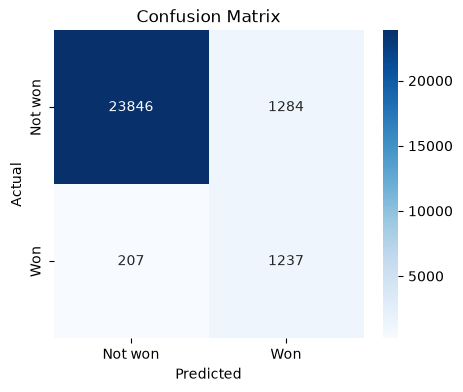

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not won', 'Won'], yticklabels=['Not won', 'Won'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

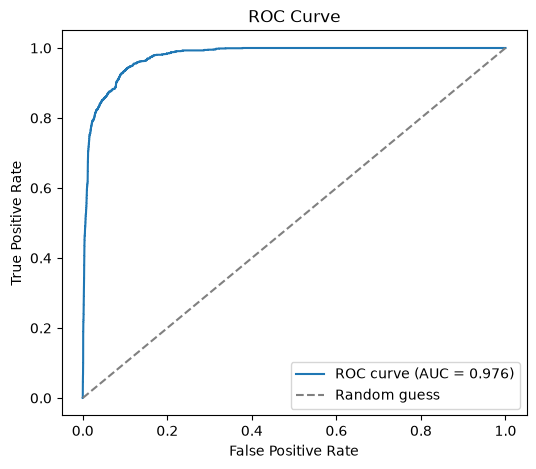

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 7. Feature importance — this is your Objective 1 answer
Unlike the linear correlation check in EDA, Random Forest importance captures non-linear effects and interactions between features.

position                    0.220421
gap_to_leader_ms            0.170498
gap_to_leader_s             0.141676
grid                        0.106010
gap_per_lap_covered_s       0.104689
gap_to_ahead_ms             0.093861
drs_zone_proxy              0.038312
pace_delta_to_fastest_ms    0.034505
position_vs_grid            0.012489
tire_age_ratio              0.007136
cum_time_ms                 0.007113
race_progress               0.006892
milliseconds                0.006686
rolling_lap_time_ms         0.006628
total_laps                  0.006391
laps_since_last_pit         0.005870
round                       0.005594
lap                         0.005426
year                        0.005304
position_change             0.003159
dtype: float64


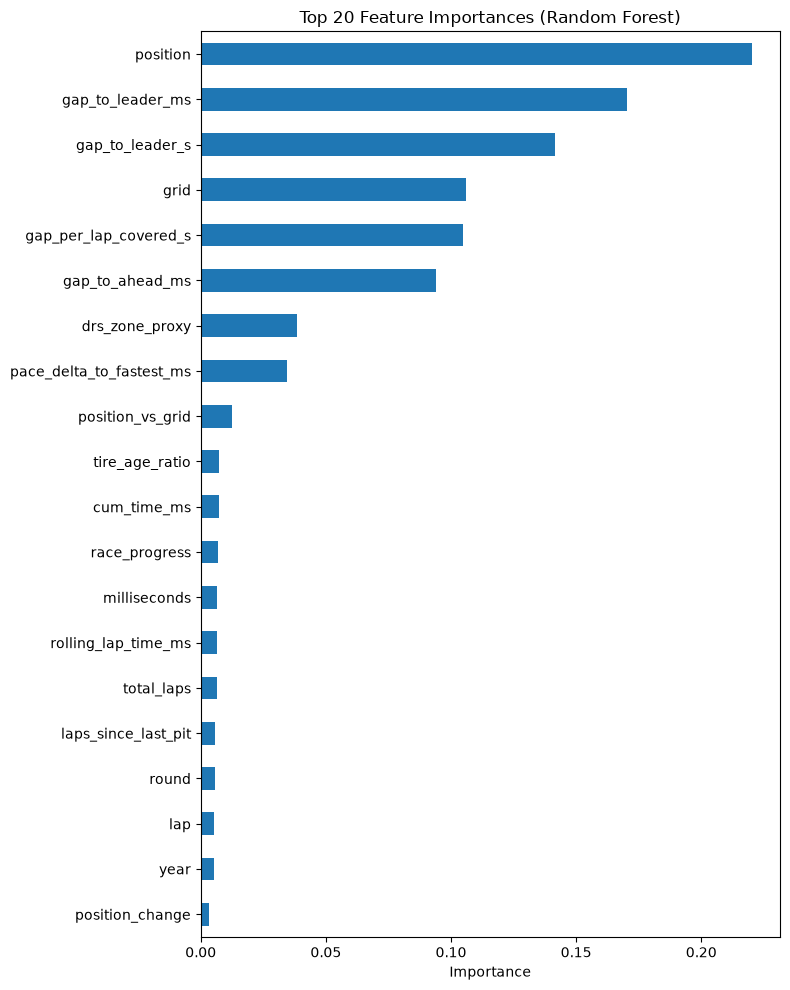

In [10]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(20))

plt.figure(figsize=(8, 10))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Save the model

In [11]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/win_probability_model.pkl')
joblib.dump(feature_cols, '../models/feature_columns.pkl')
print('Saved -> models/win_probability_model.pkl')
print('Saved -> models/feature_columns.pkl')

Saved -> models/win_probability_model.pkl
Saved -> models/feature_columns.pkl


## 9. Record results
Write actual ROC-AUC/precision/recall numbers here once run — this becomes the content for `docs/09_model_results.md`.